# NB-01: データ探索・前処理

**目的**: めぐ指数計算に必要な全データを page_reference から組み立て、品質確認と外れ値処理を実施する。

## 使用データソース
| データ | 取得元 | 利用目的 |
|---|---|---|
| race_result_flat | data/page_reference/tables/{year}/ | 走破タイム・ラップ・斤量 |
| cushion_YYYY.json | data/page_reference/cushion/ | TSI(馬場速度指数) |

## 出力
- `output/nb01/megu_dataset.parquet`: 全クリーニング済みデータ（2020-2026）
- `output/nb01/par_splits.parquet`: 基準前半スプリット（distance×surface×track_condition）

**注**: horse_stats_snapshot(獲得賞金)は現STGに未入力 → Δlevel=0として処理（FQ枠組みは維持）


In [1]:
import sys, json, warnings
sys.path.insert(0, '/home/jovyan/work/keiba-vpn')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 日本語フォント設定
plt.rcParams['axes.unicode_minus'] = False
try:
    fm.fontManager.addfont('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'
except:
    pass

OUTPUT_DIR = Path('/home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path('/home/jovyan/work/keiba-vpn/data/page_reference/tables')
CUSHION_DIR = Path('/home/jovyan/work/keiba-vpn/data/page_reference/cushion')
ALL_YEARS = [str(y) for y in range(2020, 2027)]

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup OK')


Setup OK


## 1. race_result_flat 全年ロード

In [2]:
# ── 全年 race_result_flat ロード ────────────────────────────────────────
KEEP_COLS = [
    'race_id', 'date', 'venue', 'venue_code', 'surface', 'distance',
    'direction', 'grade', 'race_class', 'weather', 'track_condition',
    'field_size', 'race_name',
    # 馬
    'horse_id', 'horse_number', 'sex_age', 'jockey_weight',
    # タイム・ラップ
    'finish_position', 'time_sec', 'last_3f', 'lap_times', 'pace',
]

parts = []
for year in ALL_YEARS:
    p = TABLES_DIR / year / 'race_result_flat.parquet'
    if not p.exists():
        print(f'SKIP {year}: not found')
        continue
    cols = [c for c in KEEP_COLS if c in pd.read_parquet(p, engine='pyarrow').columns]
    df_y = pd.read_parquet(p, columns=cols)
    df_y['year'] = int(year)
    parts.append(df_y)
    print(f'{year}: {len(df_y):,} 行')

df_raw = pd.concat(parts, ignore_index=True)
print(f'\n合計: {len(df_raw):,} 行  期間: {df_raw["date"].min()} 〜 {df_raw["date"].max()}')
print(f'surface分布:', df_raw['surface'].value_counts().to_dict())


2020: 48,282 行
2021: 47,821 行
2022: 47,220 行
2023: 47,672 行
2024: 47,181 行
2025: 47,884 行
2026: 21,011 行

合計: 307,071 行  期間: 2020-01-05 〜 2026-06-07
surface分布: {'ダート': 145727, '芝': 145269, '障': 1983}


## 2. 前半スプリットタイム計算

In [3]:
def parse_lap_times(lap_json, distance):
    """
    lap_times JSON配列 → 各区間の累積距離 + 累積タイムのDict。
    200m刻みを仮定（標準JRA ラップ）。
    Returns: {distance_m: cumulative_sec} の辞書
    """
    if pd.isna(lap_json) or not lap_json:
        return {}
    try:
        laps = json.loads(lap_json) if isinstance(lap_json, str) else lap_json
        if not laps:
            return {}
        # JRA標準: 最初の区間だけ端数（例: 1200m ÷ 6 = 200m / 1800m ÷ 9 = 200m）
        # 各区間 = distance / len(laps)
        seg_len = distance / len(laps)
        result = {}
        cumtime = 0.0
        cumdist = 0.0
        for t in laps:
            cumtime += t
            cumdist += seg_len
            result[round(cumdist)] = round(cumtime, 2)
        return result
    except:
        return {}


def select_split_point(distance, available_dists):
    """距離の50%以下で最近傍のスプリット点を選択"""
    target = distance * 0.5
    cands = [d for d in sorted(available_dists) if d <= target]
    return max(cands) if cands else None


# ── スプリット計算 ──────────────────────────────────────────────────────
print('前半スプリット計算中...')
df_flat = df_raw[df_raw['surface'].isin(['芝', 'ダート']) & df_raw['distance'].notna()].copy()
df_flat['distance'] = pd.to_numeric(df_flat['distance'], errors='coerce')
df_flat = df_flat[df_flat['distance'] > 0]

splits = []
for _, row in df_flat[['race_id','distance','lap_times']].drop_duplicates('race_id').iterrows():
    lap_dict = parse_lap_times(row['lap_times'], row['distance'])
    if not lap_dict:
        splits.append({'race_id': row['race_id'], 'front_split_sec': np.nan, 'split_point_m': np.nan})
        continue
    sp = select_split_point(int(row['distance']), list(lap_dict.keys()))
    if sp is None:
        splits.append({'race_id': row['race_id'], 'front_split_sec': np.nan, 'split_point_m': np.nan})
    else:
        splits.append({'race_id': row['race_id'], 'front_split_sec': lap_dict[sp], 'split_point_m': int(sp)})

df_splits = pd.DataFrame(splits)
print(f'スプリット計算: {len(df_splits):,} レース')
print(f'front_split_sec カバレッジ: {df_splits["front_split_sec"].notna().mean():.1%}')
print(f'split_point_m 分布:')
print(df_splits['split_point_m'].value_counts().head(10).to_dict())


前半スプリット計算中...
スプリット計算: 16,858 レース
front_split_sec カバレッジ: 96.3%
split_point_m 分布:
{800.0: 5632, 600.0: 5269, 1000.0: 2632, 756.0: 839, 1200.0: 645, 400.0: 361, 950.0: 194, 955.0: 150, 575.0: 148, 750.0: 122}


## 3. TSI（馬場速度指数）の計算

In [4]:
# ── クッション値データのロード ──────────────────────────────────────────
cushion_parts = []
for year in ALL_YEARS:
    p = CUSHION_DIR / f'cushion_{year}.json'
    if p.exists():
        data = json.loads(p.read_text())
        df_c = pd.DataFrame(data)
        cushion_parts.append(df_c)

df_cushion = pd.concat(cushion_parts, ignore_index=True)
df_cushion = df_cushion[df_cushion['is_race_day'] == True].copy()
df_cushion['date'] = pd.to_datetime(df_cushion['date'], errors='coerce')
df_cushion = df_cushion.dropna(subset=['date'])
df_cushion['date_str'] = df_cushion['date'].dt.strftime('%Y-%m-%d')
print(f'cushion data: {len(df_cushion):,} rows  期間: {df_cushion["date"].min().date()} 〜 {df_cushion["date"].max().date()}')
print(f'venue_code 種類: {df_cushion["venue_code"].nunique()}')
print(f'cushion_value 分布:')
print(df_cushion['cushion_value'].describe())

# race_result_flat に date_str を追加して cushion とマージ
df_flat['date_str'] = pd.to_datetime(df_flat['date'], errors='coerce').dt.strftime('%Y-%m-%d')
df_flat['venue_code'] = df_flat['venue_code'].astype(str).str.strip()
df_cushion['venue_code'] = df_cushion['venue_code'].astype(str).str.strip()

df_c_merge = df_cushion[['date_str','venue_code','cushion_value','turf_moisture_goal','dirt_moisture_goal']].drop_duplicates(subset=['date_str','venue_code'])
df_flat = df_flat.merge(df_c_merge, on=['date_str','venue_code'], how='left')

# TSI_raw: 芝はクッション値（高=硬=速）、ダートは含水率（高=重=遅 → 負）
df_flat['tsi_raw'] = np.where(
    df_flat['surface'] == '芝',
    df_flat['cushion_value'].fillna(df_flat.groupby(['venue_code'])['cushion_value'].transform('median')),
    -df_flat['dirt_moisture_goal'].fillna(df_flat.groupby(['venue_code'])['dirt_moisture_goal'].transform('median'))
)
print(f'\nTSI_raw カバレッジ: {df_flat["tsi_raw"].notna().mean():.1%}')
print(f'芝 TSI_raw mean: {df_flat[df_flat["surface"]=="芝"]["tsi_raw"].mean():.2f}')
print(f'ダート TSI_raw mean: {df_flat[df_flat["surface"]=="ダート"]["tsi_raw"].mean():.2f}')


cushion data: 2,176 rows  期間: 2020-09-12 〜 2026-07-04
venue_code 種類: 10
cushion_value 分布:
count   2176.0000
mean       9.2367
std        0.8921
min        5.4000
25%        8.9000
50%        9.3000
75%        9.8000
max       12.2000
Name: cushion_value, dtype: float64

TSI_raw カバレッジ: 100.0%
芝 TSI_raw mean: 9.17
ダート TSI_raw mean: -6.12


## 4. 斤量偏差（weight_dev）の計算

In [5]:
# ── 斤量偏差 ──────────────────────────────────────────────────────────
# 基準: 牡・セン = 55kg, 牝 = 53kg (55 - 2)
# weight_dev = 実斤量 - 基準斤量
# dist_scale = distance / 2000

df_flat['sex'] = df_flat['sex_age'].str.extract(r'^(牡|牝|セン)', expand=False).fillna('牡')
df_flat['age_num'] = pd.to_numeric(df_flat['sex_age'].str.extract(r'(\d+)$', expand=False), errors='coerce')
df_flat['base_weight'] = np.where(df_flat['sex'] == '牝', 53.0, 55.0)
df_flat['jockey_weight_num'] = pd.to_numeric(df_flat['jockey_weight'], errors='coerce')
df_flat['weight_dev'] = df_flat['jockey_weight_num'] - df_flat['base_weight']
df_flat['dist_scale'] = df_flat['distance'] / 2000.0

print('斤量偏差 分布:')
print(df_flat['weight_dev'].describe())
print(f'\nweight_dev カバレッジ: {df_flat["weight_dev"].notna().mean():.1%}')
print(df_flat.groupby('sex')['weight_dev'].mean().to_dict())


斤量偏差 分布:
count   231505.0000
mean         1.2192
std          1.5741
min         -7.0000
25%          0.0000
50%          1.0000
75%          2.0000
max          9.0000
Name: weight_dev, dtype: float64

weight_dev カバレッジ: 100.0%
{'牝': 1.133901817184532, '牡': 1.2823397667147667}


## 5. マスターデータセット組み立て

In [6]:
# ── スプリットをマージ ────────────────────────────────────────────────
df_main = df_flat.merge(df_splits[['race_id','front_split_sec','split_point_m']],
                         on='race_id', how='left')

# ── 走破タイム数値化 ────────────────────────────────────────────────────
df_main['finish_time_sec'] = pd.to_numeric(df_main['time_sec'], errors='coerce')
df_main['finish_pos'] = pd.to_numeric(df_main['finish_position'], errors='coerce')

# ── 走破タイムなし・障害レースを除外 ───────────────────────────────────────
df_main = df_main[df_main['finish_time_sec'].notna()]
df_main = df_main[df_main['surface'].isin(['芝', 'ダート'])]

print(f'全データ: {len(df_main):,} 行')
print(f'  芝: {(df_main["surface"]=="芝").sum():,}  ダート: {(df_main["surface"]=="ダート").sum():,}')
print(f'  期間: {df_main["date"].min()} 〜 {df_main["date"].max()}')

# ── 距離帯 ────────────────────────────────────────────────────────────
dist_bins  = [0, 1499, 1799, 2399, 9999]
dist_labels = ['sprint', 'mile', 'middle', 'long']
df_main['distance_band'] = pd.cut(df_main['distance'], bins=dist_bins, labels=dist_labels)

# ── 馬場カテゴリ → グループ化（重・不良を統合） ─────────────────────────────
track_map = {'良': '良', '稍重': '稍重', '重': '重・不良', '不良': '重・不良'}
df_main['track_cat'] = df_main['track_condition'].map(track_map).fillna('良')

print(f'\n距離帯 分布:')
print(df_main['distance_band'].value_counts().to_dict())
print(f'\ntrack_cat 分布:')
print(df_main['track_cat'].value_counts().to_dict())


全データ: 231,505 行
  芝: 133,876  ダート: 97,629
  期間: 2020-01-05 〜 2026-06-07

距離帯 分布:
{'middle': 87140, 'sprint': 86648, 'mile': 40670, 'long': 17047}

track_cat 分布:
{'良': 167921, '稍重': 37978, '重・不良': 25606}


## 6. 外れ値検出・除去

In [7]:
# ── 外れ値: 同セル内 z-score > 3.5 ──────────────────────────────────────
grp = ['distance_band', 'surface', 'track_cat']
df_main['time_mean'] = df_main.groupby(grp)['finish_time_sec'].transform('mean')
df_main['time_std']  = df_main.groupby(grp)['finish_time_sec'].transform('std')
df_main['time_z']    = (df_main['finish_time_sec'] - df_main['time_mean']) / df_main['time_std'].replace(0, np.nan)

outliers = df_main['time_z'].abs() > 3.5
print(f'外れ値 (z>3.5): {outliers.sum():,} 行 ({outliers.mean():.2%})')
df_clean = df_main[~outliers].copy()
print(f'クリーニング後: {len(df_clean):,} 行')

# ── 前半スプリット外れ値チェック ─────────────────────────────────────────
sp_valid = df_clean['front_split_sec'].notna()
print(f'\nfront_split_sec カバレッジ: {sp_valid.mean():.1%}')
if sp_valid.sum() > 0:
    print(df_clean.loc[sp_valid, 'front_split_sec'].describe())

# ── サマリー ───────────────────────────────────────────────────────────
print('\n=== データ品質サマリー ===')
print(f'  走破タイム外れ値除去: {outliers.sum():,} 行')
print(f'  最終データ: {len(df_clean):,} 行 ({df_clean["year"].min()}-{df_clean["year"].max()})')
print(f'  ユニークrace_id: {df_clean["race_id"].nunique():,}')
print(f'  front_split_sec coverage: {df_clean["front_split_sec"].notna().mean():.1%}')
print(f'  tsi_raw coverage: {df_clean["tsi_raw"].notna().mean():.1%}')
print(f'  weight_dev coverage: {df_clean["weight_dev"].notna().mean():.1%}')


外れ値 (z>3.5): 1,936 行 (0.84%)
クリーニング後: 229,569 行

front_split_sec カバレッジ: 97.0%
count   222733.0000
mean        45.8007
std         11.9572
min         21.5000
25%         34.7000
50%         47.0000
75%         51.0000
max        116.9000
Name: front_split_sec, dtype: float64

=== データ品質サマリー ===
  走破タイム外れ値除去: 1,936 行
  最終データ: 229,569 行 (2020-2026)
  ユニークrace_id: 16,858
  front_split_sec coverage: 97.0%
  tsi_raw coverage: 100.0%
  weight_dev coverage: 100.0%


## 7. 基準前半スプリット（par_front_split）の算出

In [8]:
# ── 学習データのみ（2020-2024）で par_front_split 算出 ──────────────────
# 仕様 U-2: (distance × surface × track_condition) 算術平均, 最低10件
train_years = [2020, 2021, 2022, 2023, 2024]
df_train = df_clean[df_clean['year'].isin(train_years)].copy()

# 1次集計
par_split_1 = (
    df_train.dropna(subset=['front_split_sec'])
    .groupby(['distance', 'surface', 'track_cat'])['front_split_sec']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'par_front_split_sec', 'count': 'n'})
)

# 10件未満はプーリング（surface × track_cat にフォールバック）
pooled = (
    df_train.dropna(subset=['front_split_sec'])
    .groupby(['surface', 'track_cat'])['front_split_sec']
    .mean()
    .reset_index()
    .rename(columns={'front_split_sec': 'par_split_pooled'})
)

par_split_full = par_split_1.merge(pooled, on=['surface', 'track_cat'], how='left')
par_split_full['par_front_split_final'] = np.where(
    par_split_full['n'] >= 10,
    par_split_full['par_front_split_sec'],
    par_split_full['par_split_pooled']
)
par_split_full = par_split_full[par_split_full['par_front_split_final'].notna()]

print(f'par_front_split セル数: {len(par_split_full):,}')
print(par_split_full[par_split_full['surface']=='芝'].head(10).to_string())


par_front_split セル数: 78
    distance surface track_cat  par_front_split_sec      n  par_split_pooled  par_front_split_final
3       1000       芝        稍重              22.5245    147           48.5532                22.5245
4       1000       芝         良              22.1336    901           48.2385                22.1336
5       1000       芝      重・不良              22.5243    103           48.3432                22.5243
12      1200       芝        稍重              34.0899   3654           48.5532                34.0899
13      1200       芝         良              33.9382  15545           48.2385                33.9382
14      1200       芝      重・不良              34.3262   2130           48.3432                34.3262
21      1400       芝        稍重              34.8716   1304           48.5532                34.8716
22      1400       芝         良              34.6830   9442           48.2385                34.6830
23      1400       芝      重・不良              35.0185    988           48.3432

## 8. 保存

保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01/megu_dataset.parquet  shape=(229569, 29)
par_splits 保存完了: /home/jovyan/work/keiba-vpn/notebooks/megu_index/output/nb01/par_splits.parquet


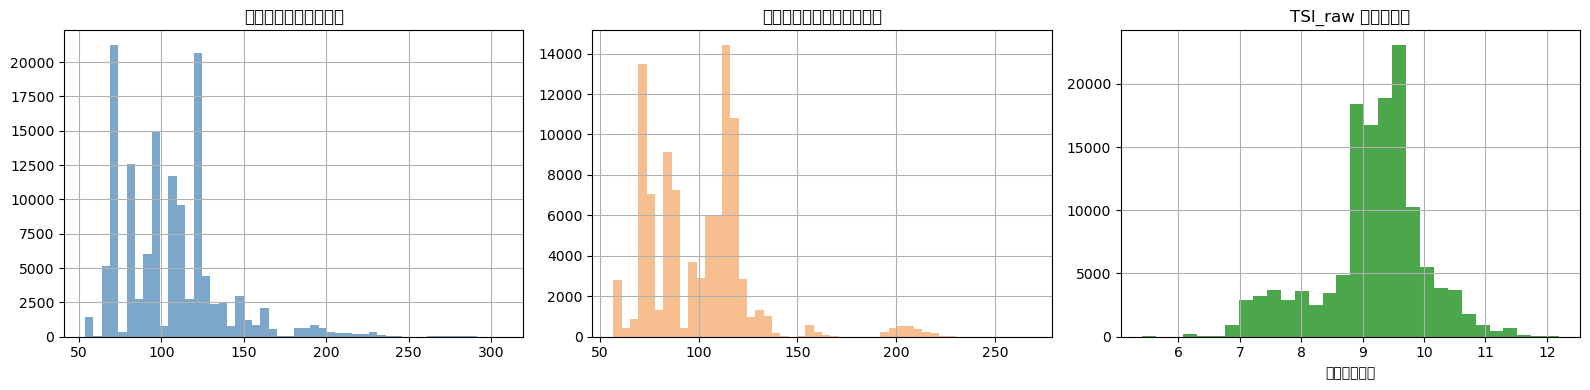

完了！


In [9]:
# ── 保存 ───────────────────────────────────────────────────────────────
SAVE_COLS = [
    'race_id', 'date', 'year', 'venue', 'venue_code', 'surface', 'distance',
    'distance_band', 'direction', 'grade', 'race_class', 'track_condition', 'track_cat',
    'weather', 'field_size',
    'horse_id', 'horse_number', 'sex', 'age_num', 'jockey_weight_num',
    'finish_pos', 'finish_time_sec', 'last_3f',
    'front_split_sec', 'split_point_m',
    'tsi_raw', 'weight_dev', 'dist_scale',
    'time_z',
]
save_cols = [c for c in SAVE_COLS if c in df_clean.columns]
df_save = df_clean[save_cols].copy()

path_out = OUTPUT_DIR / 'megu_dataset.parquet'
df_save.to_parquet(path_out, index=False)
print(f'保存完了: {path_out}  shape={df_save.shape}')

par_split_full[['distance','surface','track_cat','par_front_split_final','n']].to_parquet(
    OUTPUT_DIR / 'par_splits.parquet', index=False
)
print(f'par_splits 保存完了: {OUTPUT_DIR / "par_splits.parquet"}')

# 分布確認プロット
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, surf in zip(axes, ['芝', 'ダート', '芝']):
    sub = df_save[df_save['surface'] == surf]
    if surf == '芝' and ax == axes[2]:
        sub['tsi_raw'].hist(bins=30, ax=ax, color='green', alpha=0.7)
        ax.set_title('TSI_raw 分布（芝）')
        ax.set_xlabel('クッション値')
    elif surf == '芝':
        sub['finish_time_sec'].hist(bins=50, ax=ax, color='steelblue', alpha=0.7)
        ax.set_title('走破タイム分布（芝）')
    else:
        sub['finish_time_sec'].hist(bins=50, ax=ax, color='sandybrown', alpha=0.7)
        ax.set_title('走破タイム分布（ダート）')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_distribution.png', dpi=80)
plt.show()
print('完了！')
